In [69]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import re
from random import random
print('done')

done


In [70]:
class Tree:
    def __init__(self,root,max_bond = None,cutoff = None):
        self.nodes = {}
        self.network = None
        self.neutral = root
        self.root = root

        self.nodes[root.index] = root
        self.network = root.tensor
        self.cutoff = cutoff
        self.max_bond = max_bond

        ####### utile dans les autres fonc
    def to_str(self,node):
        return ''.join(node)

    def to_list(self,node):
        return re.findall(r'[A-Za-z]|\d+', node)

    def diff_part_str(self,A,B):
        A = self.to_list(A)
        B = self.to_list(B)

        prefix = []

        for i in range(min(len(A),len(B))):
            if A[i] == B[i]:
                prefix.append(A[i])
            else:
                break

        if not(prefix[-1].isnumeric()):
            prefix.pop()
        return prefix,A[len(prefix):],B[len(prefix):]

    def get_previous_node(self,node):
        nb = int(node[-1])
        if nb == 1:
            return node[0:-2]
        else:
            return node[0:-1]+[str(nb-1)]

    def is_adjacent(self,i,j):
        i = self.to_list(i)
        j = self.to_list(j)
        if self.get_previous_node(i) == j or self.get_previous_node(j) == i:
            return True
        else:
            return False

    def get_path_to_last_common_node(self,node,last_common_node):

        path = []
        
        previous_node = node
        while previous_node != last_common_node:
            path.append(self.to_str(previous_node))
            previous_node = self.get_previous_node(previous_node)

        path.append(self.to_str(last_common_node))
        return path

    def get_path(self,A,B):
        last_common_node,tail_A,tail_B = self.diff_part_str(A,B)

        A_to_lcn = list(reversed(self.get_path_to_last_common_node(self.to_list(A),last_common_node)))
        B_to_lcn = list(reversed(self.get_path_to_last_common_node(self.to_list(B),last_common_node)))


        for i in range(min(len(A_to_lcn),len(B_to_lcn))):
            if A_to_lcn[i] != B_to_lcn[i]:
                return list(reversed(A_to_lcn[i-1:]))+B_to_lcn[i:]
        return list(reversed(A_to_lcn[i+1:]))+B_to_lcn[i:]

    def swap_adjacent(self,i,j):
        # print('swapping ',i,j)
        array = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2)
        self.apply_2qb_gate(i,j,gate_array = array)

    
    ###### methodes

    def shift_neutral(self,i,j,side = 'right'):

        # print('called shift_neutral on ',i,j)

        if not(self.is_adjacent(i,j)):
            raise Exception('not adjacent')
        
        # get nodes
        node_1 = self.nodes[i]
        node_2 = self.nodes[j]
        # get indexes
        side_1 = list(node_1.tensor.inds)
        side_2 = list(node_2.tensor.inds)
        # print('1',side_1)
        # print('2',side_2)
        # print('nodes',node_1.tensor,node_2.tensor)

        bond_ind = (set(node_1.tensor.inds) & set(node_2.tensor.inds)).pop()
        side_1.remove(bond_ind)
        side_2.remove(bond_ind)

        # print(bond_ind)
        # print(side_1)
        # print(side_2)

        # 'apply' gate
        contracted_qubits = node_1.tensor @ node_2.tensor

        split_tensor = contracted_qubits.split(left_inds=side_1,right_inds=side_2,method='svd',absorb=side,bond_ind=bond_ind,max_bond=self.max_bond, cutoff=self.cutoff)
        
        ind_1 = split_tensor.ind_map[side_1[0]].pop()
        tensor_1 = split_tensor.tensor_map[ind_1]
        ind_2 = split_tensor.ind_map[side_2[0]].pop()
        tensor_2 = split_tensor.tensor_map[ind_2]

        tensor_1.drop_tags([j])
        tensor_2.drop_tags([i])

        result = tensor_1 & tensor_2
        node_1.tensor = tensor_1
        node_2.tensor = tensor_2

        self.network.delete(i)
        self.network.delete(j)

        self.network = self.network & node_1.tensor
        self.network = self.network & node_2.tensor


    def shift_along_path(self,node,root):
        path = self.get_path(node,root)
        # print('shifting along ',path)
        
        for i in range(len(path)-1):
            self.shift_neutral(path[i],path[i+1],side = 'right')

    def add(self,node):
        self.nodes[node.index] = node

        if self.network == None:
            self.network = node.tensor
        else:
            self.network = self.network & node.tensor

        Id = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2)
        self.apply_2qb_gate(i = node.index,j = node.up,gate_array=Id,already_linked=False)
        #canonalize
        self.shift_along_path(node.index,self.root.index)

    def apply_1qb_gate(self,i,gate_array = np.array([[1,0],[0,1]],dtype = complex)):
        node = self.nodes[i]
        gate = qtn.Tensor(data=gate_array,inds = ['out'+i,'nout'+i],tags = ['gate'])
        nqubit = self.network[i] & gate
        nqubit.contract_ind('out'+i)
        nqubit.reindex_({'nout'+i:'out'+i})
        nqubit.drop_tags('gate')

        node.tensor = nqubit[i]

        self.network.delete(i)

        self.network = self.network & nqubit

    def apply_2qb_gate(self,i,j,gate_array = np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2),side = 'right',already_linked=True):
        # print('called apply 2qb gate on ',i,j)
        # self.draw()
        swapped = False
        if not(self.is_adjacent(i,j)):
            # print('not adjacent,swapping')
            # raise Exception('not adjacent')
            path = self.get_path(i,j)
            for k in range(len(path)-2):
                self.swap_adjacent(path[k],path[k+1])
            old_i = i
            i = path[k+1]
            # print('--- swapping non adjacent over')
            swapped = True

        def sort_indexes(i,j):
            if len(i) > len(j):
                return i,j
            elif len(i) < len(j):
                return j,i
            elif int(i[-1]) > int(j[-1]):
                return i,j
            else:
                return j,i
        
        farthest_ind,closest_ind = sort_indexes(i,j)

        if already_linked:
            # print('shifting neutral to',i)
            self.shift_along_path(self.root.index,farthest_ind)
            # print('--- shifting neutral to ',i,' over')
            # self.draw()
            # print('before applying gate')
        
        # print('applying gate to',i,j)
        # get nodes
        node_1 = self.nodes[i]
        node_2 = self.nodes[j]

        #define gate
        gate = qtn.Tensor(data=gate_array,inds = ['out'+i,'out'+j,'nout'+i,'nout'+j],tags = ['gate'])

        if already_linked:
            bond_ind = j+'-'+i+'b'
        else:
            bond_ind = j+'-'+i

        #change indexes to match gate indexes

        gate = gate.split(left_inds=['out'+i,'nout'+i],method='svd',absorb='both',bond_ind=bond_ind,max_bond=self.max_bond, cutoff=self.cutoff)

        # 'apply' gate
        qubits = node_1.tensor & node_2.tensor
        qubits_and_gate = qubits & gate
        qubits_and_gate.contract_ind('out'+i)
        qubits_and_gate.contract_ind('out'+j)

        qu.tensor.tensor_fuse_squeeze(qubits_and_gate[i],qubits_and_gate[j])

        qubits_and_gate.reindex_({'nout'+i:'out'+i,'nout'+j:'out'+j})
        qubits_and_gate.drop_tags('gate')

        node_1.tensor = qubits_and_gate[i]
        node_2.tensor = qubits_and_gate[j]

        self.network.delete(i)
        self.network.delete(j)

        self.network = self.network & qubits_and_gate
        # print('gate applied on ',i,j)
        # self.draw()
        # print('after applying gate')

        if swapped:
            # print('swapping back')
            for k in range(1,len(path)-1):
                # print(k)
                self.swap_adjacent(path[:-1][-k],path[:-1][-k-1])
            # print('--- swapping back over')

        if already_linked:
            # print('putting neutral back to root from ',i)
            self.shift_along_path(farthest_ind,self.root.index)
        # print('draw after last shift')
        # self.draw()
        
    
    def draw(self):
        return self.network.draw(show_tags=True, show_inds='all',iterations=100, k=6)

    def swap(self,A,B):
        path = self.get_path(A,B)
        for i in range(len(path)-1):
            self.swap_adjacent(path[i],path[i+1])

class Node:
    def __init__(self,index,up,childrens,up_bdim,childrens_bdim):
        self.index = index
        self.up = up
        self.childrens = childrens
        self.up_bdim = up_bdim
        self.childrens_bdim = childrens_bdim
        self.init_tensor()
    
    def init_tensor(self):
        self.tensor = qtn.Tensor(data=np.array([1,0],dtype=complex),inds=['out'+self.index],tags = [self.index])

    def reindex(self,dic):
        self.tensor.reindex_(dic)

        for i in dic.keys():
            if self.up == i:
                self.up = dic[i]
            if i in self.childrens:
                self.childrens.remove(i)
                self.childrens.append(dic[i])

In [53]:
for p in range(10):
    R0 = Node(index='R0',up = None,up_bdim = 0,childrens=['R0A1','R0B1'],childrens_bdim = [2,2])
    R0A1 = Node(index='R0A1',up = 'R0',up_bdim = 2,childrens=['R0A2'],childrens_bdim = [2])
    R0A2 = Node(index='R0A2',up = 'R0A1',up_bdim = 2,childrens=[],childrens_bdim = [])
    R0B1 = Node(index='R0B1',up = 'R0',up_bdim = 2,childrens=['R0B1A1','R0B1B1'],childrens_bdim = [2,2])
    R0B1A1 = Node(index='R0B1A1',up = 'R0B1',up_bdim = 2,childrens=[],childrens_bdim = [2])
    R0B1B1 = Node(index='R0B1B1',up = 'R0B1',up_bdim = 2,childrens=[],childrens_bdim = [2])

    Tree1 = Tree(R0,max_bond = 8,cutoff = None)
    Tree1.add(R0A1)
    Tree1.add(R0A2)
    Tree1.add(R0B1)
    Tree1.add(R0B1A1)
    Tree1.add(R0B1B1)



    # Tree1.network.draw(show_tags=True, show_inds='all',iterations=100, k=4)

    print('***************** finished building tree **********************')

    # Tree1.swap_adjacent('R0A1','R0A2')
    # Tree1.apply_2qb_gate('R0A2','R0',gate_array = np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]],dtype=complex).reshape(2,2,2,2))
    # Tree1.shift_neutral('R0A1','R0A2',side = 'left')
    # Tree1.network.draw(show_tags=True, show_inds='all',iterations=100, k=4)


    translation_dic = {'R0':0,'R0A1':1,'R0A2':2,'R0B1':3,'R0B1A1':4,'R0B1B1':5}
    qubits = ['R0','R0A1','R0A2','R0B1','R0B1A1','R0B1B1']
    shuffled_qubits = qubits.copy()

    circ = qtn.Circuit(6)

    reindex_dic = {}
    for i in range(len(qubits)):
        reindex_dic['k'+str(i)] = 'out'+qubits[i]
    # print(reindex_dic)
    # net.draw(show_tags=True, show_inds='all',iterations=100, k=4)


    N_gates = 100
    ############# Gates
    # Tree1.apply_1qb_gate(i = 'R0',gate_array=np.array([[1/np.sqrt(2),1/np.sqrt(2)],[1/np.sqrt(2),-1/np.sqrt(2)]],dtype=complex))
    # circ.apply_gate('H',translation_dic['R0'])
    rng = np.random.default_rng()

    for i in range(N_gates):
        rng.shuffle(shuffled_qubits)
        if random() < 0.5:
            # print('Applied H to ', shuffled_qubits[0],translation_dic[shuffled_qubits[0]])
            Tree1.apply_1qb_gate(i = shuffled_qubits[0],gate_array=np.array([[1/np.sqrt(2),1/np.sqrt(2)],[1/np.sqrt(2),-1/np.sqrt(2)]],dtype=complex))
            circ.apply_gate('H',translation_dic[shuffled_qubits[0]])
        else:
            # print('Applied CNOT to ', shuffled_qubits[0],shuffled_qubits[1],translation_dic[shuffled_qubits[0]],translation_dic[shuffled_qubits[1]])
            Tree1.apply_2qb_gate(i = shuffled_qubits[0],j = shuffled_qubits[1],gate_array=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=complex).reshape(2,2,2,2))
            circ.apply_gate('CNOT',translation_dic[shuffled_qubits[0]],translation_dic[shuffled_qubits[1]])   
            

    #############

    net = circ.psi.reindex_(reindex_dic)

    # print('********* Tree data')
    # for k in Tree1.network.tensor_map.keys():
    #     print('--',Tree1.network.tensor_map[k])
    #     print(k,Tree1.network.tensor_map[k].data)

    # print('********* circ')

    # for k in net.tensor_map.keys():
    #     print('--',net.tensor_map[k])
    #     print(k,net.tensor_map[k].data)

    # fnet = Tree1.network & net

    # print('*********  final circ')
    # for k in fnet.tensor_map.keys():
    #     print('--',fnet.tensor_map[k])
    #     print(k,fnet.tensor_map[k].data)

    ############

    fnet = net & Tree1.network
    # fnet.draw(show_tags=True, show_inds='all',iterations=100, k=4)
    print(float(np.real(fnet.contract())))

***************** finished building tree **********************
0.9999999999999509
***************** finished building tree **********************
0.9999999999999479
***************** finished building tree **********************
0.9999999999999549
***************** finished building tree **********************
0.9999999999999408
***************** finished building tree **********************
0.9999999999999551
***************** finished building tree **********************
0.9999999999999458
***************** finished building tree **********************
0.9999999999999543
***************** finished building tree **********************
0.9999999999999536
***************** finished building tree **********************
0.9999999999999589
***************** finished building tree **********************
0.9999999999999503


In [71]:
def Test_Tree(N_gates = 10,max_bond=None,cutoff=None):
    R0 = Node(index='R0',up = None,up_bdim = 0,childrens=['R0A1','R0B1'],childrens_bdim = [2,2])
    R0A1 = Node(index='R0A1',up = 'R0',up_bdim = 2,childrens=['R0A2'],childrens_bdim = [2])
    R0A2 = Node(index='R0A2',up = 'R0A1',up_bdim = 2,childrens=[],childrens_bdim = [])
    R0B1 = Node(index='R0B1',up = 'R0',up_bdim = 2,childrens=['R0B1A1','R0B1B1'],childrens_bdim = [2,2])
    R0B1A1 = Node(index='R0B1A1',up = 'R0B1',up_bdim = 2,childrens=[],childrens_bdim = [2])
    R0B1B1 = Node(index='R0B1B1',up = 'R0B1',up_bdim = 2,childrens=[],childrens_bdim = [2])

    Tree1 = Tree(R0,max_bond = max_bond,cutoff = cutoff)
    Tree1.add(R0A1)
    Tree1.add(R0A2)
    Tree1.add(R0B1)
    Tree1.add(R0B1A1)
    Tree1.add(R0B1B1)

    translation_dic = {'R0':0,'R0A1':1,'R0A2':2,'R0B1':3,'R0B1A1':4,'R0B1B1':5}
    qubits = ['R0','R0A1','R0A2','R0B1','R0B1A1','R0B1B1']
    shuffled_qubits = qubits.copy()

    circ = qtn.Circuit(6)

    reindex_dic = {}
    for i in range(len(qubits)):
        reindex_dic['k'+str(i)] = 'out'+qubits[i]

    rng = np.random.default_rng()

    for i in range(N_gates):
        rng.shuffle(shuffled_qubits)
        if random() < 0.5:
            # print('Applied H to ', shuffled_qubits[0],translation_dic[shuffled_qubits[0]])
            Tree1.apply_1qb_gate(i = shuffled_qubits[0],gate_array=np.array([[1/np.sqrt(2),1/np.sqrt(2)],[1/np.sqrt(2),-1/np.sqrt(2)]],dtype=complex))
            circ.apply_gate('H',translation_dic[shuffled_qubits[0]])
        else:
            # print('Applied CNOT to ', shuffled_qubits[0],shuffled_qubits[1],translation_dic[shuffled_qubits[0]],translation_dic[shuffled_qubits[1]])
            Tree1.apply_2qb_gate(i = shuffled_qubits[0],j = shuffled_qubits[1],gate_array=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=complex).reshape(2,2,2,2))
            circ.apply_gate('CNOT',translation_dic[shuffled_qubits[0]],translation_dic[shuffled_qubits[1]])   
            
    net = circ.psi.reindex_(reindex_dic)

    fnet = net & Tree1.network
    return(np.real(fnet.contract()))

# for p in range(10):
#     print(Test_Tree(N_gates=100,max_bond=7,cutoff=None))


chi_values = []
N_values = []
error_values = []

chi_range = range(2,20,1) 
N_range = range(10,200,10)

# print(Test_Tree(N_gates=20,max_bond=10))

for chi in chi_range:
    for N in N_range:
        chi_values.append(chi)
        N_values.append(N)
        moy = []
        for i in range(10):
            moy.append(1-Test_Tree(N_gates=N,max_bond=chi))
        error_values.append(np.mean(moy))

        

print(chi_values,N_values,error_values)

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17,

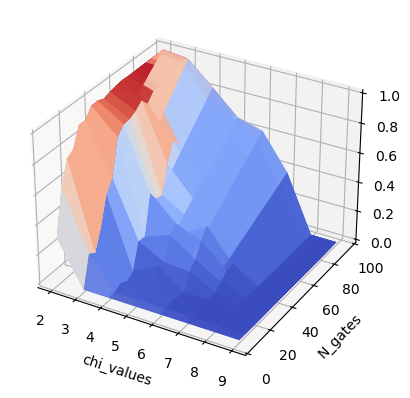

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

grid_x, grid_y = np.meshgrid(chi_values,N_values)

# Interpolate Z values onto the grid
grid_z = griddata((chi_values, N_values), error_values, (grid_x, grid_y), method='cubic')

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, grid_z, alpha = 0.7,cmap='coolwarm')

ax.contour(X, Y, Z, zdir='x', offset=-15, cmap='coolwarm')
ax.contour(X, Y, Z, zdir='y', offset=100, cmap='coolwarm')

ax.set_xlabel('chi_values')
ax.set_ylabel('N_gates')
ax.set_zlabel('error')

plt.show()

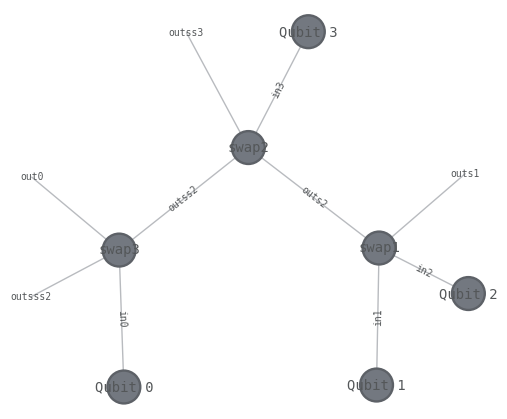

In [35]:
state1 = np.array([0,1])

qb0 = qtn.Tensor(data=state1,inds=['in0'],tags = ['Qubit 0'])
qb1 = qtn.Tensor(data=state1,inds=['in1'],tags = ['Qubit 1'])
qb2 = qtn.Tensor(data=state1,inds=['in2'],tags = ['Qubit 2'])
qb3 = qtn.Tensor(data=state1,inds=['in3'],tags = ['Qubit 3'])

Id1 = qtn.Tensor(data=np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2),
                    inds = ['in1','in2','outs1','outs2'],tags = ['Id1'])

Id2 = qtn.Tensor(data=np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2),
                    inds = ['in3','outs2','outss2','outss3'],tags = ['Id2'])

Id3 = qtn.Tensor(data=np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2),
                    inds = ['in0','outss2','out0','outsss2'],tags = ['Id3'])

TN = qb0 & qb1 & qb2 & qb3 & swap1 & swap2 & swap3

TN.draw(show_tags=True, show_inds='all',iterations=100, k=4)

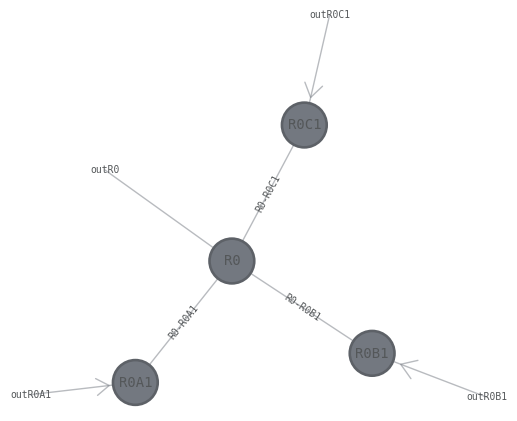

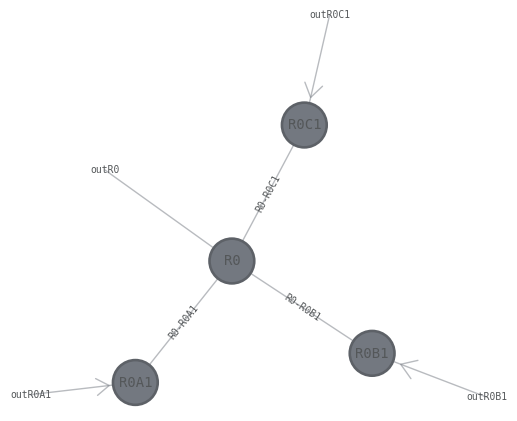

In [ ]:
R0 = Node(index='R0',up = None,up_bdim = 0,childrens=['R0A1','R0B1','R0C1'],childrens_bdim = [2,2,2])
RA1 = Node(index='R0A1',up = 'R0',up_bdim = 2,childrens=[],childrens_bdim = [])
RA2 = Node(index='R0B1',up = 'R0',up_bdim = 2,childrens=[],childrens_bdim = [])
RB1 = Node(index='R0C1',up = 'R0',up_bdim = 2,childrens=[],childrens_bdim = [])

Tree1 = Tree(R0)
Tree1.add(RA1)
Tree1.add(RA2)
Tree1.add(RB1)

Tree1.network.draw(show_tags=True, show_inds='all',iterations=100, k=4)

# Tree1.swap_adjacent('R0A1','R0A2')
# Tree1.swap('R0A2','R0')
# Tree1.shift_neutral('R0A1','R0A2',side = 'left')
# Tree1.network.draw(show_tags=True, show_inds='all',iterations=100, k=4)

In [ ]:
circ = qtn.CircuitMPS(2)
# circ.apply_2qb_gate('H', regs[0])
# circ.apply_2qb_gate('CNOT', regs[0], regs[1])

# circ.psi.draw()
circ.psi.tensor_map

{0: Tensor(shape=(1, 2), inds=('_4d78a5AAACY', 'k0'), tags=oset(['I0', 'PSI0'])),
 1: Tensor(shape=(1, 2), inds=('_4d78a5AAACY', 'k1'), tags=oset(['I1', 'PSI0']))}

In [434]:
R0 = Node(index='R0',up = None,up_bdim = 0,childrens=['R0A1'],childrens_bdim = [2])
RA1 = Node(index='R0A1',up = 'R0',up_bdim = 2,childrens=[],childrens_bdim = [])
RA2 = Node(index='R0B1',up = 'R0',up_bdim = 2,childrens=[],childrens_bdim = [])
RB1 = Node(index='R0C1',up = 'R0',up_bdim = 2,childrens=[],childrens_bdim = [])



Tree3 = Tree(R0)
Tree3.add(RA1)
Tree3.add(RA2)

# H = np.array([[1/np.sqrt(2),1/np.sqrt(2)],[1/np.sqrt(2),-1/np.sqrt(2)]])
# Not = np.array([[0,1],[1,0]])

# Tree3.apply_1qb_gate(i = 'R0A1',gate_array=Not)
# # Tree3.swap('R0A1','R0')
Tree3.apply_2qb_gate(i = 'R0A2',j = 'R0',gate_array = np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]]).reshape(2,2,2,2))
# # Tree1.add(RA2)
# # Tree1.add(RB1)

Tree3.network.draw(show_tags=True, show_inds='all',iterations=100, k=4)

['R0A2', 'R0A1', 'R0']


KeyError: 'R0A2'

In [225]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np

# Define tensors
T1 = qtn.Tensor(data=np.array([0, 1],dtype=complex), inds=['outR0'], tags=['R0'])
T2 = qtn.Tensor(data=np.array([0, 1],dtype=complex), inds=['outR0A1'], tags=['R0A1'])

# Create a network
net = qtn.TensorNetwork([T1, T2])
print(net.tensor_map[1].data)
print(net.tensor_map[1].data)

# Define a CNOT gate
# cnot = qu.CNOT()

# Apply the gate
qtn.tensor_network_gate_inds(self=net,
    G=np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]],dtype=float),
    inds=['outR0', 'outR0A1'],
    contract='split-gate',
    inplace = True,
    bond_ind = 'test'
    # compress_opts = {'method':'svd','absorb':'right','outR0-outR0A1':'bond_ind','left_inds':'outT1'}
)

net.draw(show_tags=True, show_inds='all',iterations=100, k=4)
# print(net.tensor_map[1].data)


# T1b = qtn.Tensor(data=np.array([0, 1]), inds=['outR0'], tags=['R0'])
# T2b = qtn.Tensor(data=np.array([0, 1]), inds=['outR0A1'], tags=['R0A1'])

# netb = qtn.TensorNetwork([T1b, T2b])

# fnet = net & netb
# fnet.draw(show_tags=True, show_inds='all',iterations=100, k=4)

# fnet.contract()


# net5 = circ.psi.reindex_({'k0':'outR0','k1':'outR0A1'})
# net5.draw(show_tags=True, show_inds='all',iterations=100, k=4)

# fnet = Tree3.network & net5
# fnet.contract()

[0.+0.j 1.+0.j]
[0.+0.j 1.+0.j]


TypeError: quimb.tensor.tensor_core.tensor_split() got multiple values for keyword argument 'bond_ind'